wtg01 merged!
wtg02 merged!
wtg03 merged!
wtg04 merged!
wtg05 merged!
wtg06 merged!
wtg07 merged!
wtg08 merged!
wtg09 merged!
All DataLoad & Merge Complete!


c:\Users\yunju\anaconda3\envs\windpower\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


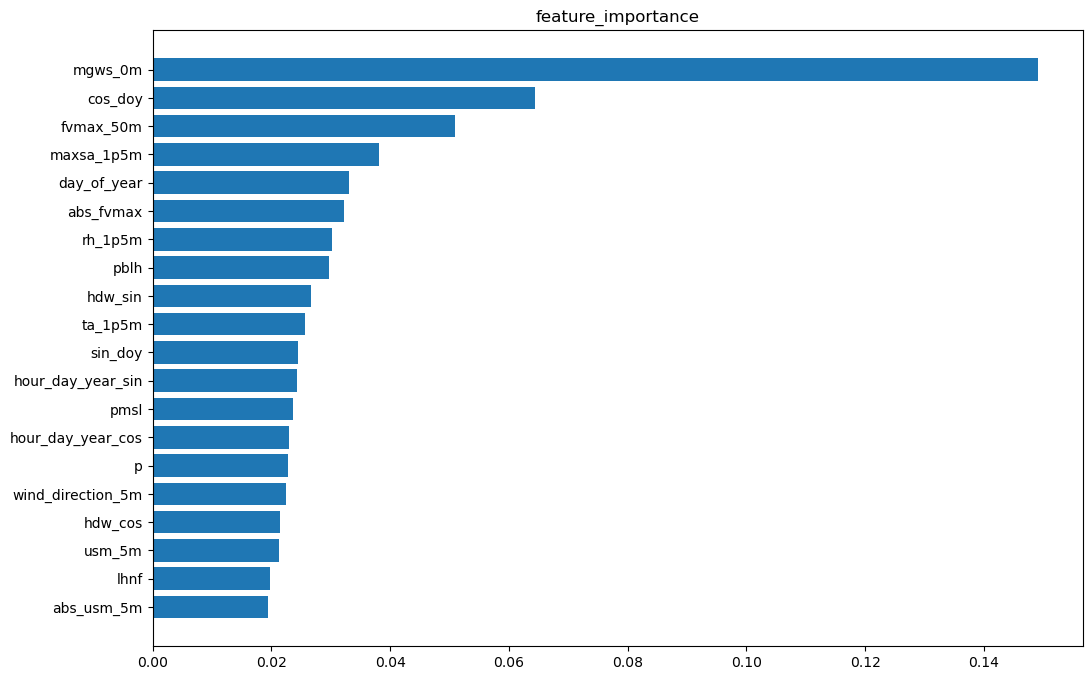

NMAE: 12.723244969741652


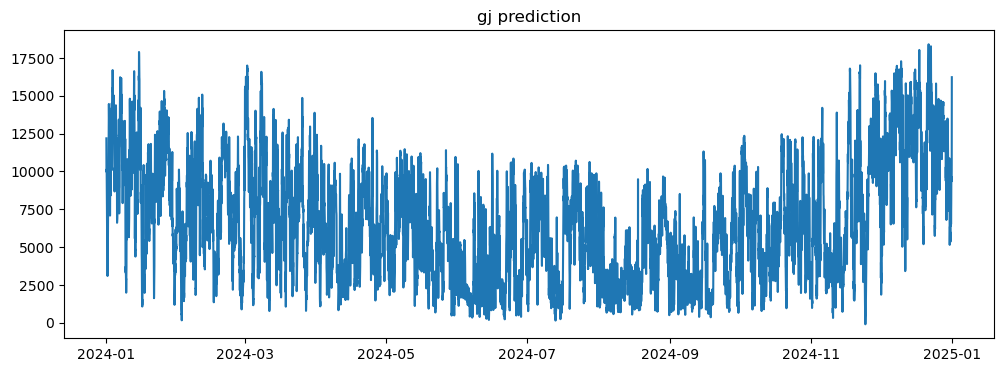

경주 예측 저장 위치: 경주_모델/경주_예측/경주.csv


In [1]:
import 경주_main_rf

all weather & wtg data merged complete!
all weather & wtg data merged complete!


c:\Users\yunju\anaconda3\envs\windpower\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


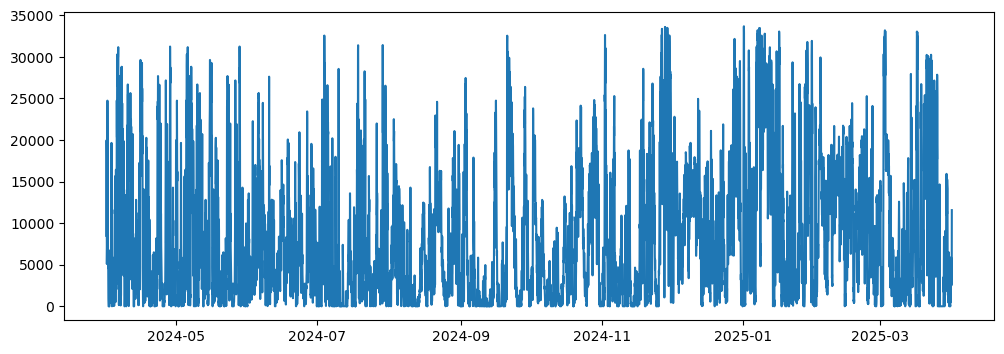

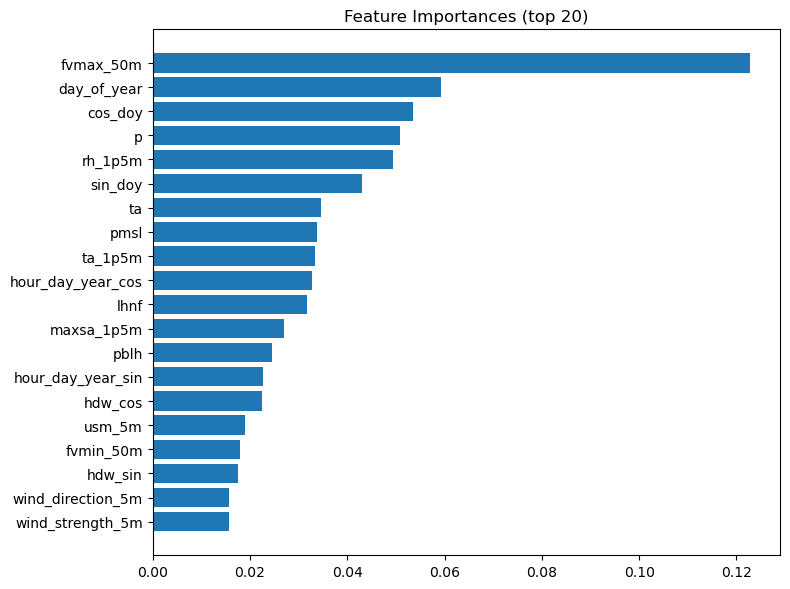

NMAE: 9.83887545422424
양양 예측 저장 위치: 양양_모델/양양_예측/양양_baseline.csv


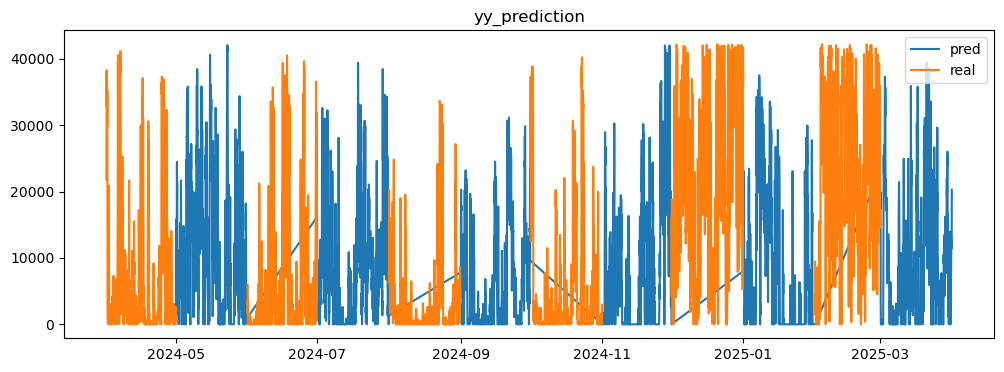

c:\Users\yunju\anaconda3\envs\windpower\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


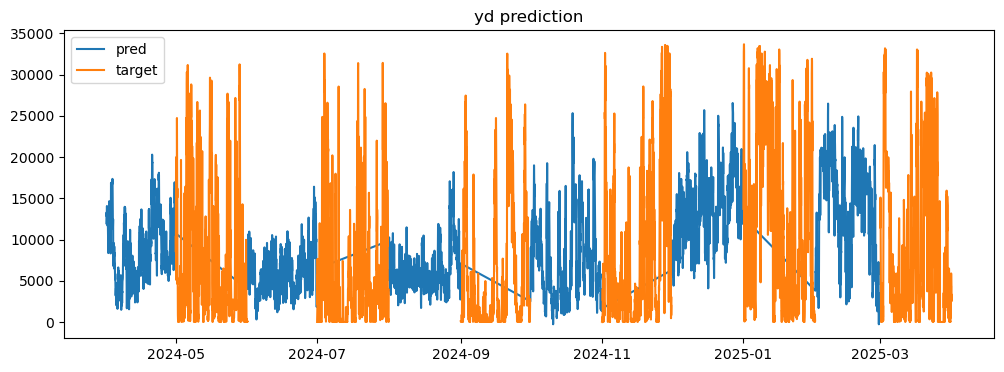

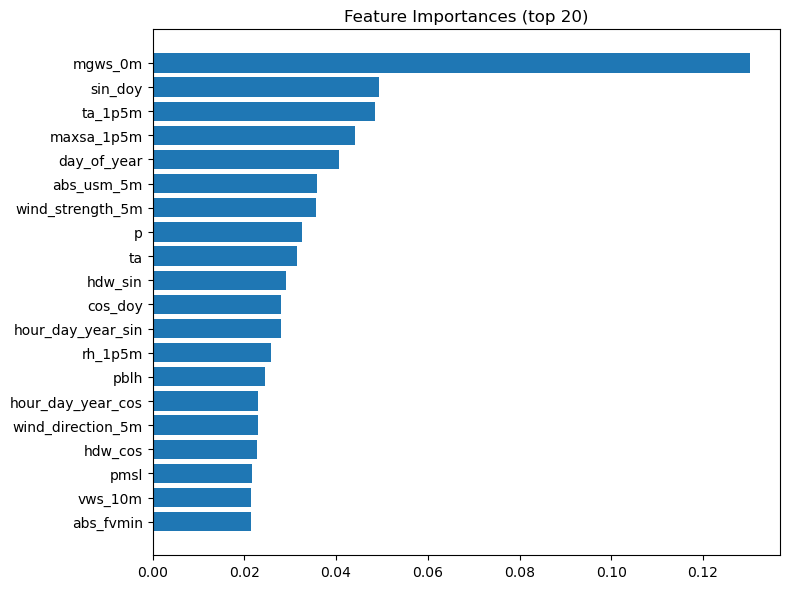

NMAE: 8.750486285772196
영덕 예측 저장 위치: 영덕_모델/영덕_예측/영덕_baseline.csv


In [2]:
import 양양_영덕_예측

In [3]:
import pandas as pd

yy = pd.read_csv("양양_모델/양양_예측/양양_baseline.csv")
yd = pd.read_csv("영덕_모델/영덕_예측/영덕_baseline.csv")
gj_df = pd.read_csv("경주_모델/경주_예측/경주.csv")

In [4]:

gj_df["plant_name"] = "경주풍력"
gj_df["Unnamed: 0"] = pd.to_datetime(gj_df["Unnamed: 0"])
gj_df["start_datetime"] = gj_df["Unnamed: 0"] - pd.Timedelta(hours = 1)
gj_df["end_datetime"] = gj_df["Unnamed: 0"]
gj_df["yield_kwh"] = gj_df["pred"]

gj = gj_df.drop(["Unnamed: 0", "pred"], axis = 1)


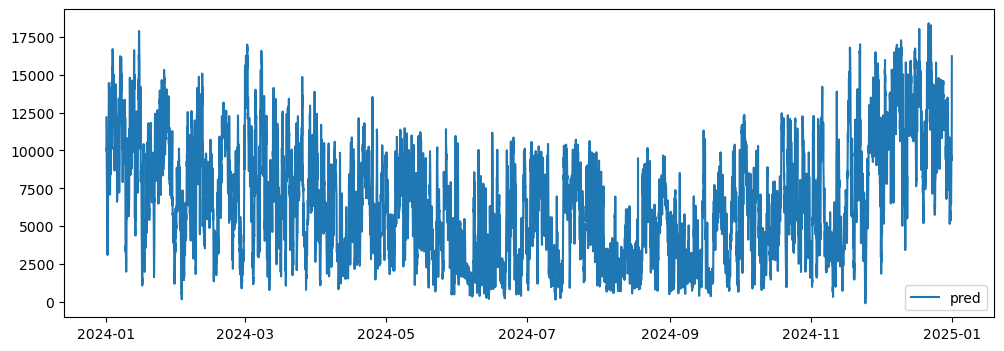

In [5]:
import matplotlib.pyplot as plt
plt.figure(figsize = (12,4))
plt.plot(gj["end_datetime"], gj["yield_kwh"], label = "pred")
plt.legend()
plt.show()

In [6]:
pred = pd.concat([gj, yy, yd], axis= 0)

pred

,plant_name,start_datetime,end_datetime,yield_kwh
0,경주풍력,2024-01-01 00:00:00,2024-01-01 01:00:00,12190.671621
1,경주풍력,2024-01-01 01:00:00,2024-01-01 02:00:00,9978.498291
2,경주풍력,2024-01-01 02:00:00,2024-01-01 03:00:00,10129.594316
3,경주풍력,2024-01-01 03:00:00,2024-01-01 04:00:00,10063.971367
4,경주풍력,2024-01-01 04:00:00,2024-01-01 05:00:00,9322.446143
...,...,...,...,...
4339,영덕풍력,2025-02-28 19:00:00,2025-02-28 20:00:00,355.832568
4340,영덕풍력,2025-02-28 20:00:00,2025-02-28 21:00:00,94.437695
4341,영덕풍력,2025-02-28 21:00:00,2025-02-28 22:00:00,731.845693
4342,영덕풍력,2025-02-28 22:00:00,2025-02-28 23:00:00,1723.793364


In [7]:
pred = pred.reset_index(drop = True)

In [8]:
pred.to_csv("result.csv", index = False)